# Problem Set 2

In [1]:
import numpy as np
import math
import random

1.1 Calculate sin(0.1) using it's taylor expansion to order 5

The Taylor series for $\sin(x)$ is:

$$
\sin(x) = \sum_{n=0}^{\infty} (-1)^n \frac{x^{2n+1}}{(2n+1)!}
$$


In [2]:
print(f"Actual value of sin(0.1): {np.sin(0.1)}")

# Using Taylor series expansion for sin(x) up to x^5 term
x = 0.1
num_of_terms = 5
taylor_expan = sum(((-1)**n * x**(2*n + 1)) / math.factorial(2*n + 1) for n in range(num_of_terms)) #Goes thorough each term of the series from n=0 to n=4
print(f"Approximate value for sin(0.1) using taylor expan: {taylor_expan}")
print(f"Difference: {abs(np.sin(0.1) - taylor_expan)}")

Actual value of sin(0.1): 0.09983341664682815
Approximate value for sin(0.1) using taylor expan: 0.09983341664682815
Difference: 0.0


In [3]:
def taylor_expansion(x: float, terms: int):
    '''
    Calculate sin(x) using its Taylor series expansion up to the specified number of terms.

    Parameters:
    x (float): The value to calculate sin(x) for.
    terms (int): The number of terms to include in the Taylor series expansion.

    Returns:
    float: The approximate value of sin(x) using the Taylor series expansion.
    '''
    return sum(((-1)**n * x**(2*n + 1)) / math.factorial(2*n + 1) for n in range(terms))

In [4]:
taylor_expansion(0.1, 5)

0.09983341664682815

1.2 Print the result as a descriptive string stating the order expanded to and value to 5 decimal places

In [5]:
def taylor_expansion(x: float, terms: int):
    '''
    Calculate sin(x) using its Taylor series expansion up to the specified number of terms.

    Parameters:
    x (float): The value to calculate sin(x) for.
    terms (int): The number of terms to include in the Taylor series expansion.

    Returns:
    float: The approximate value of sin(x) using the Taylor series expansion.
    '''
    for n in range(terms):
        term = ((-1)**n * x**(2*n + 1)) / math.factorial(2*n + 1)
        print(f"Term {n}: {round(term, 5)}")
    return round(sum(((-1)**n * x**(2*n + 1)) / math.factorial(2*n + 1) for n in range(terms)),5)

In [6]:
taylor_expansion(0.1, 5)

Term 0: 0.1
Term 1: -0.00017
Term 2: 0.0
Term 3: -0.0
Term 4: 0.0


0.09983

1.3 Construct a function which returns a list of prime numbers less than a given integer, N

In [7]:
def prime_numbers_less_than_N(N: int):
    '''
    Returns a list of prime numbers less than the given integer N.

    Parameters:
    N (int): The upper limit to find prime numbers below.

    Returns:
    list: A list of prime numbers less than N.
    '''

    prime_nums = [] #When you see list, you must create an empty list to store the numbers somewhere.
    for num in range(2, N-1):
        for i in range(2, int(np.sqrt(num))+1):
            if num % i ==0:
                break
        else:
            prime_nums.append(num)
    return prime_nums

In [8]:
prime_numbers_less_than_N(15)

[2, 3, 5, 7, 11, 13]

1.4 Construct a function which returns a list of the first N terms in the Recaman's sequence
### Recamán's Sequence

The Recamán's sequence is defined recursively as:

$$
a_0 = 0
$$

and for \( n > 0 \):

$$
a_n =
\begin{cases}
a_{n-1} - n, & \text{if } a_{n-1} - n > 0 \text{ and not already in the sequence} \\
a_{n-1} + n, & \text{otherwise.}
\end{cases}
$$

**Example (first few terms):**

0, 1, 3, 6, 2, 7, 13, 20, 12, 21, ...


### Recamán’s Sequence Flowchart

```text
          ┌────────────────────────────┐
          │  test_num = a[n-1] - n     │
          └──────────────┬─────────────┘
                         │
                         ▼
              ┌────────────────────────────┐
              │ Is test_num > 0 and        │
              │ not in recamans_list ?     │
              └──────────────┬─────────────┘
                     yes     │      no
                             │
            ┌────────────────┴────────────────┐
            ▼                                 ▼
┌───────────────────────┐        ┌──────────────────────────┐
│ append(test_num)      │        │ append(a[n-1] + n)       │
└───────────────────────┘        └──────────────────────────┘


In [9]:
def recamans_sequence(N: int):
    '''
    Returns the first N terms of the Recaman's Sequence.

    Parameters:
    N: The first n terms given.

    Returns:
    list: A list of the terms in the sequence.
    '''

    recamans_list = [0]
    for n in range(1,N):
        test_num = recamans_list[n-1] - n
        if test_num > 0 and test_num not in recamans_list:
            recamans_list.append(test_num)
        else:
            recamans_list.append(recamans_list[n-1]+n)
    return recamans_list

In [10]:
recamans_sequence(10)

[0, 1, 3, 6, 2, 7, 13, 20, 12, 21]

1.5 Compute a list of the numbers which appear in both lists when they are both N items long.

In [11]:
def compare_prime_recamans(N: int):
    '''
    Compares the prime list output and the recamans list output to see which numbers appear in both

    Parameters:
    N: An integer to run the list of terms

    Returns:
    list: A list of numbers.
    '''

    recamans_list = recamans_sequence(N)
    prime_list = prime_numbers_less_than_N(N)
    print(f"Recamans list is: {recamans_list}")
    print(f"Prime list is: {prime_list}")
    common_list = list(set(recamans_list) & set(prime_list))
    return common_list

In [12]:
compare_prime_recamans(15)

Recamans list is: [0, 1, 3, 6, 2, 7, 13, 20, 12, 21, 11, 22, 10, 23, 9]
Prime list is: [2, 3, 5, 7, 11, 13]


[2, 3, 7, 11, 13]

1.6 Create a list of all pairs of factors (as tuples) of 362880 using list comprehension.

In this question, we had to use % and //.
% called modulus operator: gives the remainder after the division. Therefore when we say n % i == 0, we are really say that when the number divides completely against i, so no remainder, then that is a factor,cofactor pairing. 10 / 5 = 2 no remainder, so 5 is the factor, 2 is the cofactor.
// called integer division: gives the cofactor

In [13]:
def pairs_of_factors(n: int):
    '''
    Returns a list of all pairs of factors as tuples of a given number

    
    '''
    factors_list = []
    for i in range (1,int(np.sqrt(n))+1):
        if n % i == 0:
            factors_list.append((i, n // i))

    return factors_list

In [14]:
print(10 % 5)
print(10 // 5)
print(10 % 4) #Output is 2 because 10 / 4 is 2 remainder 2
print(10 // 4)

0
2
2
2


In [15]:
pairs_of_factors(362880)

[(1, 362880),
 (2, 181440),
 (3, 120960),
 (4, 90720),
 (5, 72576),
 (6, 60480),
 (7, 51840),
 (8, 45360),
 (9, 40320),
 (10, 36288),
 (12, 30240),
 (14, 25920),
 (15, 24192),
 (16, 22680),
 (18, 20160),
 (20, 18144),
 (21, 17280),
 (24, 15120),
 (27, 13440),
 (28, 12960),
 (30, 12096),
 (32, 11340),
 (35, 10368),
 (36, 10080),
 (40, 9072),
 (42, 8640),
 (45, 8064),
 (48, 7560),
 (54, 6720),
 (56, 6480),
 (60, 6048),
 (63, 5760),
 (64, 5670),
 (70, 5184),
 (72, 5040),
 (80, 4536),
 (81, 4480),
 (84, 4320),
 (90, 4032),
 (96, 3780),
 (105, 3456),
 (108, 3360),
 (112, 3240),
 (120, 3024),
 (126, 2880),
 (128, 2835),
 (135, 2688),
 (140, 2592),
 (144, 2520),
 (160, 2268),
 (162, 2240),
 (168, 2160),
 (180, 2016),
 (189, 1920),
 (192, 1890),
 (210, 1728),
 (216, 1680),
 (224, 1620),
 (240, 1512),
 (252, 1440),
 (270, 1344),
 (280, 1296),
 (288, 1260),
 (315, 1152),
 (320, 1134),
 (324, 1120),
 (336, 1080),
 (360, 1008),
 (378, 960),
 (384, 945),
 (405, 896),
 (420, 864),
 (432, 840),
 (448

1.7 Write a generator function for a random walk, step size 1, which is equally likely to go up or down. End
the generator when you have total displacement of 10 steps (you will need a random number generator like
random.randint(a,b) which gives a random integer between a and b inclusive, you will need to add the line
import random at the top in order to use it).

In [16]:
#condition when the total displacement abs(pos) = 10 then break else continue
def random_walk():
    '''
    A random walk generator with step size 1.

    Parameters:
    None

    Returns:
    pos: a list of all steps taken.
    '''
    pos = 0
    while abs(pos)<10:
        step = random.randint(0,1)
        #Taken from class notes
        #position += 1 if random.randint(0,1) else -1
        #yield position
        if step == 0:
            pos +=-1
        else:
            pos += 1
        yield pos
    return pos

In [17]:
for p in random_walk():
    print(p)

-1
-2
-3
-2
-3
-2
-3
-4
-3
-2
-1
-2
-1
-2
-3
-4
-5
-4
-3
-4
-3
-2
-1
-2
-3
-4
-3
-2
-3
-2
-1
0
-1
-2
-1
0
1
2
1
2
1
2
3
4
5
6
7
8
7
8
9
10


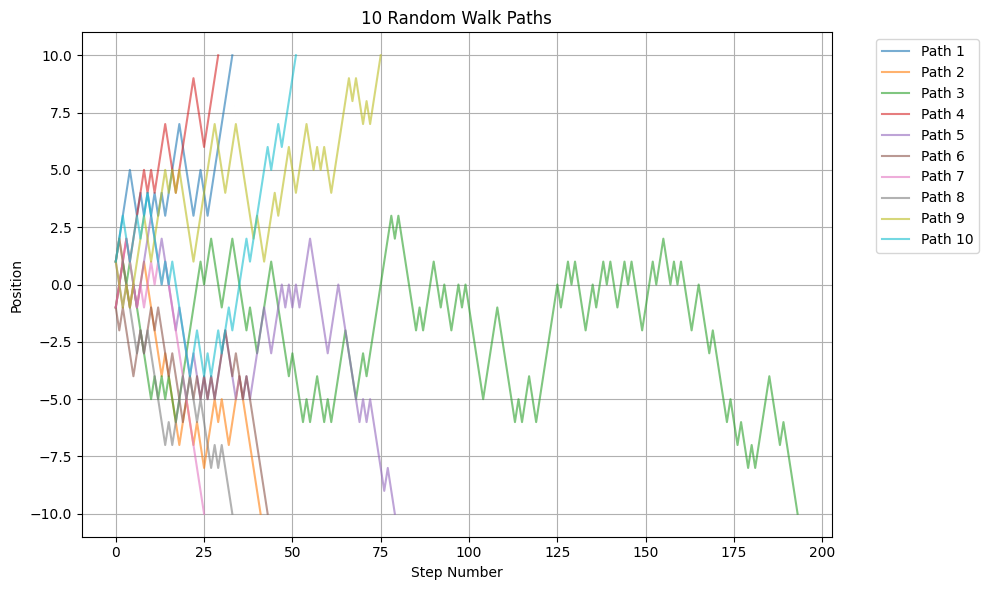

In [18]:
# Generate 10 random walk paths
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for i in range(10):
    path = list(random_walk())
    steps = list(range(len(path)))
    plt.plot(steps, path, '-', alpha=0.6, label=f'Path {i+1}')

plt.grid(True)
plt.xlabel('Step Number')
plt.ylabel('Position')
plt.title('10 Random Walk Paths')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Geometric Brownian Motion Simulation Package

Geometric Brownian motion is a stochastic process that grows multiplicatively. It follows the stochastic differential equation (SDE):

$$
dY(t) = \mu Y(t)\,dt + \sigma Y(t)\,dB(t)
$$

where \( B(t) \) is Brownian motion, \( \mu \) is the drift, and \( \sigma \) is the diffusion coefficient.  
The solution is:

$$
Y(t) = Y_0 \exp\left(\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma B(t)\right)
$$

Goal: create a Python package `pygbm` that simulates GBM using an object-oriented design.

### Requirements

- Package name: `pygbm`
- Base class + derived class(es)
- Method to simulate GBM path
- Command-line interface (CLI)
- Ability to run code like:

```python
from pygbm import GBM
import matplotlib.pyplot as plt

gbm = GBM(mu=0.05, sigma=0.2, y0=1.0)
t, y = gbm.simulate(t_end=1.0, n_steps=1000)

plt.plot(t, y)
plt.show()


Definitions:
Stochastic process = a system that evolves over time with randomness. Stock price is a collection of random variables over time.

From classwork
Brownian motion (on a real line):
A (random path) in a Brownian motion is a map from [0, \infty] (time) to a real line. 
At time 0, the path starts at 0.

If X_t\in R be a Brownian motion, t\geq 0. X_t\in R is a family of random variable.

As t increases, x_t increases.

Independent Gaussian increment: if 0< t_1 < t_2 < ...

then X_{t_1} - X_0, X_{t_2} - X_{t_1}, X_{t_3} - X_{t_2},... are independent (Markov property). These increments are also Gaussian with mean 0 and variance t_{i+1} - t_i.
